In [15]:
!pip install -q youtube-transcript-api langchain-community langchain-openai \
               faiss-cpu tiktoken python-dotenv


[notice] A new release of pip available: 22.2.2 -> 26.2.1
[notice] To update, run: C:\Users\karan\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [16]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langchain_community.tools.tavily_search import TavilySearchResults


from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
import operator
from typing import List, Annotated
from langchain_core.messages import BaseMessage

load_dotenv()

C:\Users\karan\AppData\Local\Temp\ipykernel_2776\3783069777.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS
c:\Users\karan\Desktop\langgraph\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\karan\AppData\Local\Temp\ipykernel_2776\3783069777.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS
c:\Users\karan\Desktop\langgraph\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


False

In [17]:
!pip install -q youtube-transcript-api 


[notice] A new release of pip available: 22.2.2 -> 26.2.1
[notice] To update, run: C:\Users\karan\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


# data prepration

In [18]:
from youtube_transcript_api import YouTubeTranscriptApi, TranscriptsDisabled
YT_WATCH_ID = "OYvlznJ4IZQ"

try:
  ytt_api = YouTubeTranscriptApi()
  transcipt = ytt_api.fetch(YT_WATCH_ID)
  print(transcipt)
except TranscriptsDisabled as e:
  print(e)
except Exception as e:
  print(e)

FetchedTranscript(snippets=[FetchedTranscriptSnippet(text='Hi everyone, this is GKCS.', start=0.24, duration=1.68), FetchedTranscriptSnippet(text="In today's video we will see some of\nthe commonly used terms in the AI space.", start=1.92, duration=3.4), FetchedTranscriptSnippet(text='If you are an engineer\nwho is building applications,', start=5.76, duration=1.84), FetchedTranscriptSnippet(text='then you will find these terms useful.', start=7.6, duration=1.52), FetchedTranscriptSnippet(text='When communicating with people\nwithin your team or outside.', start=9.12, duration=3.0), FetchedTranscriptSnippet(text='And I think if you know these terms,', start=12.4, duration=1.56), FetchedTranscriptSnippet(text='then it is also easier to learn\nthe deeper subjects around AI.', start=13.96, duration=3.64), FetchedTranscriptSnippet(text="So by the end of this video,\nyou'll have a list of terms", start=18.24, duration=2.24), FetchedTranscriptSnippet(text='whose definitions you understand\nq

In [19]:
for text in transcipt.snippets:
  print(text)
  break

FetchedTranscriptSnippet(text='Hi everyone, this is GKCS.', start=0.24, duration=1.68)


In [20]:
# documents = [
#     Document(
#         page_content=snippet.text,
#         metadata={
#             "start": snippet.start,
#             "end": snippet.start + snippet.duration,
#             "source": YT_WATCH_ID
#         }
#     )
#     for snippet in transcipt.snippets
# ]
# len(documents)

In [21]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter


# 1. Combine transcript snippets into one continuous text
full_text = " ".join(
    snippet.text for snippet in transcipt.snippets
)


# 2. Create a mapping from character position → timestamp
char_timestamps = []

current_position = 0

for snippet in transcipt.snippets:
    text = snippet.text
    start = snippet.start

    char_timestamps.append({
        "start_char": current_position,
        "end_char": current_position + len(text),
        "start_seconds": start
    })

    current_position += len(text) + 1  # +1 for the space


# 3. Split the continuous transcript
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150
)

text_chunks = splitter.create_documents([full_text])


# 4. Attach timestamp metadata to every chunk
chunks = []

for chunk in text_chunks:
    chunk_start = full_text.find(chunk.page_content)

    # Find transcript snippet containing the beginning of this chunk
    timestamp = 0.0

    for item in char_timestamps:
        if item["start_char"] <= chunk_start < item["end_char"]:
            timestamp = item["start_seconds"]
            break

    chunks.append(
        Document(
            page_content=chunk.page_content,
            metadata={
                "start": timestamp,
                "source": YT_WATCH_ID
            }
        )
    )


print("Number of chunks:", len(chunks))

for i, chunk in enumerate(chunks[:3]):
    print(f"\n--- CHUNK {i} ---")
    print(chunk.page_content)
    print("Length:", len(chunk.page_content))
    print("Metadata:", chunk.metadata)

Number of chunks: 42

--- CHUNK 0 ---
Hi everyone, this is GKCS. In today's video we will see some of
the commonly used terms in the AI space. If you are an engineer
who is building applications, then you will find these terms useful. When communicating with people
within your team or outside. And I think if you know these terms, then it is also easier to learn
the deeper subjects around AI. So by the end of this video,
you'll have a list of terms whose definitions you understand
quite well. And I'll also be linking some references in the description
so that you can dig into them further. Let's start. The first term that you should know about is large language model. Also known as LM. And the definition
of this is a neural network. That is trained to predict the next term. Of an input sequence. For example, if I pass in the query all that glitters to a large language model, then it's going to come up with the response of is not going okay. At which point the complete response
Length: 9

In [22]:
from langchain_huggingface import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

from langchain_community.vectorstores import FAISS


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6437.77it/s]


In [23]:

vector_db = FAISS.from_documents(
    chunks,
    embedding_model
)

In [24]:
retriever = vector_db.as_retriever(
    search_kwargs={"k": 3}
)

query = "What is discussed about neural networks?"

results = retriever.invoke(query, k=3)

for doc in results:
    print(doc.page_content)
    print(doc.metadata)
    print("---")

Hi everyone, this is GKCS. In today's video we will see some of
the commonly used terms in the AI space. If you are an engineer
who is building applications, then you will find these terms useful. When communicating with people
within your team or outside. And I think if you know these terms, then it is also easier to learn
the deeper subjects around AI. So by the end of this video,
you'll have a list of terms whose definitions you understand
quite well. And I'll also be linking some references in the description
so that you can dig into them further. Let's start. The first term that you should know about is large language model. Also known as LM. And the definition
of this is a neural network. That is trained to predict the next term. Of an input sequence. For example, if I pass in the query all that glitters to a large language model, then it's going to come up with the response of is not going okay. At which point the complete response
{'start': 0.24, 'source': 'OYvlznJ4IZQ'}
---
is

In [25]:
for i, chunk in enumerate(chunks[:10]):
    print(f"\n--- CHUNK {i} ---")
    print(chunk.page_content)
    print("Length:", len(chunk.page_content))
    print("Metadata:", chunk.metadata)


--- CHUNK 0 ---
Hi everyone, this is GKCS. In today's video we will see some of
the commonly used terms in the AI space. If you are an engineer
who is building applications, then you will find these terms useful. When communicating with people
within your team or outside. And I think if you know these terms, then it is also easier to learn
the deeper subjects around AI. So by the end of this video,
you'll have a list of terms whose definitions you understand
quite well. And I'll also be linking some references in the description
so that you can dig into them further. Let's start. The first term that you should know about is large language model. Also known as LM. And the definition
of this is a neural network. That is trained to predict the next term. Of an input sequence. For example, if I pass in the query all that glitters to a large language model, then it's going to come up with the response of is not going okay. At which point the complete response
Length: 952
Metadata: {'start'

# LLM of the project

In [30]:
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
# Main LLM
google_llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    api_key=GOOGLE_API_KEY,
)


groq_llm = ChatGroq(
    model="openai/gpt-oss-120b",  # or "llama-3.1-8b-instant"
    temperature=0.2,
    max_retries=2,
    api_key=GROQ_API_KEY
)


# Now Langgraph

In [47]:
from typing import Annotated, TypedDict, Literal
import operator

from langchain_core.messages import BaseMessage
from langchain_core.documents import Document


class GraphState(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]

    decision_route: Literal["chat", "go_for_rag"]

    documents: list[Document]

    grade: dict

    web_search_needed: bool

    web_results: list[dict]

    context: str

    rewritten_query: str

    retry_count: int

In [80]:
class RouteDecision(BaseModel):
    decision_route: Literal["chat", "go_for_rag"]

router_llm = groq_llm.with_structured_output(RouteDecision)

def make_decision_route(state: GraphState):
    question = state["messages"][-1].content

    prompt = f"""
You are a routing agent for a YouTube RAG chatbot.

Your job is to decide whether the user's message should be handled as normal conversation or answered using information from the YouTube video/transcript.

Return ONLY one of these two values:

chat
go_for_rag

### Use "chat" when:

The user is having normal conversation or casual interaction that does not require information from the video.

Examples:

* "Hi"
* "Hello"
* "How are you?"
* "Thanks"
* "Okay"
* "Bye"
* "What can you do?"

### Use "go_for_rag" when:

The user asks anything that is related to, based on, or could be answered using information from the YouTube video/transcript.

This includes:

* Asking about a concept or topic explained in the video
* Asking for an explanation of something discussed in the video
* Asking what the speaker said or explained
* Asking for a summary of the video or a part of it
* Asking about examples mentioned in the video
* Asking why or how something works when it is discussed in the video
* Asking about specific people, technologies, ideas, terms, or topics mentioned in the video
* Asking follow-up questions about something previously discussed from the video
* Asking questions that require understanding the video's content

Examples:
"What is self-supervised learning?"
→ go_for_rag

"Explain what the video says about LLMs."
→ go_for_rag

"What examples of self-supervised learning were mentioned?"
→ go_for_rag

"Why is self-supervised learning useful?"
→ go_for_rag

"Can you summarize this video?"
→ go_for_rag

"What did the speaker say about transformers?"
→ go_for_rag

"If the video discusses RAG, explain how it works."
→ go_for_rag

### Important:

If the question could reasonably require information from the YouTube video, choose "go_for_rag".

When you are unsure whether the question is casual conversation or requires video information, choose "go_for_rag".

Do not answer the user's question. Only classify it.

User message:
{state["messages"][-1].content}

Return ONLY:
chat
OR
go_for_rag

"""

    response = groq_llm.invoke(prompt)

    decision = response.content.strip().lower()

    if decision not in ["chat", "go_for_rag"]:
        decision = "go_for_rag"

    return {"decision_route": decision}

In [49]:
# state = {
#     "messages": [HumanMessage(content="what inside the video?")]
# }

# result = make_decision_route(state)

# print(result)

In [50]:
def route_question(state: GraphState):
    return state["decision_route"]

In [51]:
def chat_node(state: GraphState):

    response = google_llm.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

In [52]:
def retrieve_node(state: GraphState):

    question = state["messages"][-1].content

    documents = retriever.invoke(question)

    return {
        "documents": documents
    }

In [53]:
from pydantic import BaseModel, Field
from typing import Literal


class ContextGrade(BaseModel):

    relevance: int = Field(
        description="How relevant the retrieved context is to the question. Score 0-10."
    )

    completeness: int = Field(
        description="How completely the context answers the question. Score 0-10."
    )

    specificity: int = Field(
        description="How specifically the context addresses the exact question. Score 0-10."
    )

    confidence: int = Field(
        description="How confident we can be that the context supports a correct answer. Score 0-10."
    )

    action: Literal[
        "generate",
        "rewrite_query",
        "web_search"
    ] = Field(
        description="Corrective action to take based on the retrieved context."
    )

    reason: str = Field(
        description="Short explanation for the grading decision."
    )

In [54]:
grader_llm = google_llm.with_structured_output(ContextGrade)


def grade_documents(state: GraphState):

    question = state["messages"][-1].content

    documents = state.get("documents", [])

    context = "\n\n".join(
        doc.page_content
        for doc in documents
    )

    prompt = f"""
You are the corrective grading agent in a YouTube C-RAG system.

Your job is to evaluate whether the retrieved YouTube transcript
is good enough to answer the user's question.

Score:

1. relevance: 0-10
2. completeness: 0-10
3. specificity: 0-10
4. confidence: 0-10

Then choose exactly ONE action:

generate
rewrite_query
web_search


Use "generate" when:
- The transcript is relevant.
- The transcript contains enough information.
- The answer can be safely generated from the transcript.

Use "rewrite_query" when:
- The retrieved documents are poorly relevant.
- The retrieval query appears to have missed the correct part of the transcript.
- A better query could reasonably retrieve better information from the YouTube transcript.

Use "web_search" when:
- The transcript does not contain the required information.
- The user explicitly asks for internet/web research.
- The question requires current/latest information.
- The required information is outside the video's scope.

Important:
Do NOT choose rewrite_query just because the answer is not in the transcript.
If the information genuinely does not exist in the transcript,
choose web_search.

User Question:
{question}

Retrieved YouTube Context:
{context}
"""

    result = grader_llm.invoke(prompt)

    overall_score = (
        result.relevance
        + result.completeness
        + result.specificity
        + result.confidence
    ) / 4

    grade = {
        "relevance": result.relevance,
        "completeness": result.completeness,
        "specificity": result.specificity,
        "confidence": result.confidence,
        "overall_score": overall_score,
        "action": result.action,
        "reason": result.reason
    }

    return {
        "grade": grade,
        "web_search_needed": result.action == "web_search"
    }

In [77]:
rewrite_prompt = """
You are a query rewriting agent for a YouTube RAG system.

Rewrite the user's question into a concise search query
that is more likely to retrieve the correct information
from the YouTube transcript.

Do not answer the question.

Return only the rewritten search query.

Original question:
{question}

Previous retrieved context:
{context}
"""


def rewrite_query_node(state: GraphState):

    question = state["messages"][-1].content

    documents = state.get("documents", [])

    context = "\n\n".join(
        doc.page_content
        for doc in documents
    )

    prompt = rewrite_prompt.format(
        question=question,
        context=context
    )

    response = google_llm.invoke(prompt)

    rewritten_query = response.content.strip()

    return {
        "rewritten_query": rewritten_query,
        "retry_count": state.get("retry_count", 0) + 1
    }

In [56]:
def retrieve_node(state: GraphState):

    if state.get("rewritten_query"):
        query = state["rewritten_query"]
    else:
        query = state["messages"][-1].content

    documents = retriever.invoke(query)

    return {
        "documents": documents
    }

In [57]:
# # GRADE_THRESHOLD = 7


# # def grade_route(state: GraphState):

# #     grade = state["grade"]

# #     if grade["needs_web_search"]:
# #         return "web_search"

# #     if grade["overall_score"] >= GRADE_THRESHOLD:
# #         return "generate"

# #     return "web_search"

# def grade_route(state: GraphState):

#     grade = state["grade"]

#     action = grade["action"]

#     retry_count = state.get("retry_count", 0)

#     if action == "generate":
#         return "generate"

#     if action == "rewrite_query":

#         if retry_count < 1:
#             return "rewrite_query"

#         return "web_search"

#     if action == "web_search":
#         return "web_search"

#     return "generate"

In [58]:
GRADE_THRESHOLD = 7
MAX_RETRIES = 2

def grade_route(state):
    grade = state["grade"]
    action = grade["action"]
    retry_count = state.get("retry_count", 0)

    if action == "web_search":
        return "web_search"

    if grade.get("overall_score", 0) < GRADE_THRESHOLD:
        if retry_count < MAX_RETRIES:
            return "rewrite_query"
        return "web_search"

    if action == "rewrite_query":
        if retry_count < MAX_RETRIES:
            return "rewrite_query"
        return "web_search"

    return "generate"

In [59]:
%pip install -q tavily-python

from tavily import TavilyClient

tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
from langchain_core.tools import tool


@tool
def tavily_search(query: str):
    """
    Search the internet for additional information
    when the YouTube transcript does not contain enough information.
    """

    response = tavily_client.search(
        query=query,
        search_depth="basic",
        max_results=5
    )

    return response["results"]

In [64]:
def web_search_node(state: GraphState):

    question = state["messages"][-1].content

    results = tavily_search.invoke(question)

    return {
        "web_results": results
    }

In [65]:
def context_fusion_node(state: GraphState):

    youtube_context = "\n\n".join(
        doc.page_content
        for doc in state.get("documents", [])
    )

    web_context = "\n\n".join(
        f"""
Title: {result.get("title", "")}
Source: {result.get("url", "")}
Content:
{result.get("content", "")}
"""
        for result in state.get("web_results", [])
    )

    final_context = f"""
===== YOUTUBE TRANSCRIPT =====

{youtube_context}

===== WEB SEARCH RESULTS =====

{web_context}
"""

    return {
        "context": final_context
    }

In [66]:
from langchain_core.prompts import ChatPromptTemplate


generate_prompt = ChatPromptTemplate.from_template("""
You are an AI assistant answering questions about a YouTube video.

Use the provided context to answer the user's question.

Rules:
- Use only information supported by the provided context.
- Do not invent information.
- If web search results are provided, they are additional information.
- Clearly distinguish information from the YouTube transcript and web sources when useful.
- If the available context does not contain enough information, say so honestly.
- Keep the answer clear and relevant.

Context:
{context}

Question:
{question}
""")


def generate_node(state: GraphState):

    question = state["messages"][-1].content

    # If context fusion already created context
    if state.get("context"):
        context = state["context"]

    else:
        # Use YouTube documents directly
        context = "\n\n".join(
            doc.page_content
            for doc in state.get("documents", [])
        )

    chain = generate_prompt | google_llm

    response = chain.invoke({
        "context": context,
        "question": question
    })

    return {
        "messages": [response]
    }

In [67]:
def reset_request_state(state: GraphState):
    return {
        "retry_count": 0,
        "rewritten_query": "",
        "context": "",
        "web_results": [],
        "documents": [],
        "grade": {},
    }

In [83]:
from langgraph.graph import StateGraph, START, END


builder = StateGraph(GraphState)


builder.add_node("reset_request_state", reset_request_state)
builder.add_node("router", make_decision_route)
builder.add_node("chat", chat_node)

builder.add_node("retriever", retrieve_node)
builder.add_node("grader", grade_documents)

builder.add_node("rewrite_query", rewrite_query_node)

builder.add_node("web_search", web_search_node)
builder.add_node("context_fusion", context_fusion_node)

builder.add_node("generate", generate_node)


builder.add_edge(START, "reset_request_state")
builder.add_edge("reset_request_state", "router")


builder.add_conditional_edges(
    "router",
    route_question,
    {
        "chat": "chat",
        "go_for_rag": "retriever"
    }
)


builder.add_edge("chat", END)


builder.add_edge("retriever", "grader")


builder.add_conditional_edges(
    "grader",
    grade_route,
    {
        "generate": "generate",
        "rewrite_query": "rewrite_query",
        "web_search": "web_search"
    }
)


builder.add_edge("rewrite_query", "retriever")


builder.add_edge("web_search", "context_fusion")


builder.add_edge("context_fusion", "generate")


builder.add_edge("generate", END)

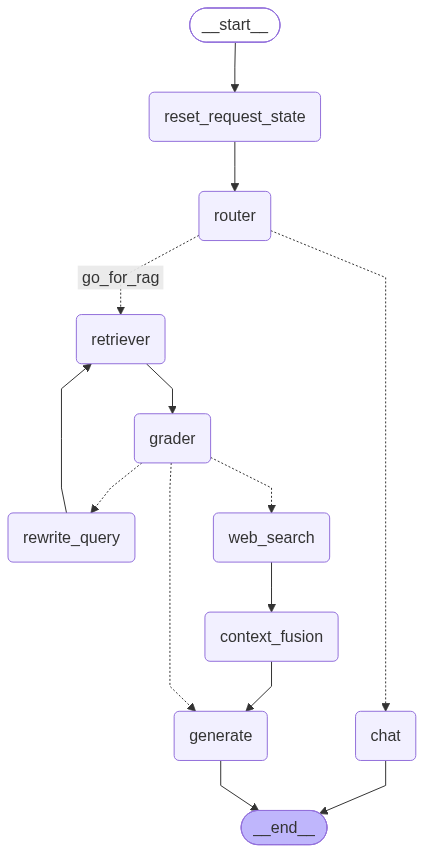

In [84]:
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()
graph = builder.compile(
    checkpointer=memory
)
graph

In [70]:
from langchain_core.messages import HumanMessage

config = {
    "configurable": {
        "thread_id": "youtube-chat-1"
    }
}

for event in graph.stream(
    {
        "messages": [
            HumanMessage(content="What ll")
        ]
    },
    config=config,
    stream_mode="updates"
):
    for node_name, output in event.items():
        print(f"\n--- {node_name} ---")
        print(output)


--- reset_request_state ---
{'retry_count': 0, 'rewritten_query': '', 'context': '', 'web_results': [], 'documents': [], 'grade': {}}



--- reset_request_state ---
{'retry_count': 0, 'rewritten_query': '', 'context': '', 'web_results': [], 'documents': [], 'grade': {}}


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.



--- reset_request_state ---
{'retry_count': 0, 'rewritten_query': '', 'context': '', 'web_results': [], 'documents': [], 'grade': {}}


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.



--- router ---
{'decision_route': 'go_for_rag'}

--- retriever ---
{'documents': [Document(id='2a310fa2-51f3-46fa-9a38-a234d4106a6b', metadata={'start': 431.4, 'source': 'OYvlznJ4IZQ'}, page_content="anything else that we have seen earlier. Okay, because it is able to derive\ncontextual meaning, it's able to construct sentences\nin a way that humans speak. Okay, so now we know how LMS can process input. But how do you train them to predict the next token? Okay, here's where there was a major breakthrough in 2017. Basically the concept of self-supervised learning. Became very popular. Self-supervised learning means that instead of telling the model\nexactly what it needs to do, the structure of the input data is such\nthat the model knows what it should do. Okay. For example, you're watching this video\nright now. I'm going to make a part of this video\nblank. So 12345. What do you think is being hidden\nright now? What number is coming to your mind? Let's see if that is right. Yes, mo

In [71]:
output['messages'][0].content

[{'type': 'text',
  'text': 'According to the video, this process is called **self-supervised learning**, which became a popular concept around 2017.\n\nThe video explains that with self-supervised learning, instead of telling the model exactly what to do, the input data is structured in a way that allows the model to determine what it needs to do on its own. The benefits of this approach include:\n\n*   **Understanding structure and meaning:** The model learns the underlying structure and inherent meaning of the data (such as terms in text, patches in images, or how objects move in videos).\n*   **Methodology:** This is achieved by removing parts of the data—such as blanking out a number in a sequence, removing patches of an image, or obscuring parts of a video—and having the model attempt to predict the missing information.',
  'extras': {'signature': 'EnMKcQFpFH0T5E/CbLyuvwH68SCHzh7QDlwUzoADC+YRLW7ha8ZMrI/Kwq2HV65hdLxN+QvMcKHhlfbzdUnsen7+LQjPqsPp7i/Zxrs5Y/bO+bTFF562h9WiYnBDsKNHdzTnu

In [82]:
assert grade_route({"grade": {"overall_score": 3, "action": "generate"}}) == "rewrite_query"
assert grade_route({"grade": {"overall_score": 3, "action": "generate"}, "retry_count": 1}) == "rewrite_query"
assert grade_route({"grade": {"overall_score": 3, "action": "generate"}, "retry_count": 2}) == "web_search"
assert grade_route({"grade": {"overall_score": 9, "action": "rewrite_query"}, "retry_count": 2}) == "web_search"
assert grade_route({"grade": {"overall_score": 3, "action": "web_search"}}) == "web_search"
assert grade_route({"grade": {"overall_score": 9, "action": "web_search"}}) == "web_search"
assert grade_route({"grade": {"overall_score": 9, "action": "generate"}}) == "generate"
print("Grade routing checks passed")

Router, message parsing, and bounded retry checks passed
